In [ ]:
import pandas as pd 
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)


In [2]:
from datetime import datetime,date
import plotly.express as px
import plotly.graph_objects as go
import plotly.colors
import matplotlib.pyplot as plt
import seaborn as sns




In [3]:
data = pd.read_csv('Sales Dataset.csv')
data.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12


In [4]:
data.tail()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
1189,B-26370,8825,3594,15,Furniture,Tables,Debit Card,2024-07-31,Megan Mclean,New York,New York City,2024-07
1190,B-26298,2082,642,8,Electronics,Phones,EMI,2020-06-02,Caitlin Hunt,New York,Rochester,2020-06
1191,B-26298,2082,642,8,Electronics,Phones,EMI,2022-12-15,Jenna Holland,Texas,Austin,2022-12
1192,B-26298,2082,642,8,Electronics,Phones,EMI,2020-08-07,Stephanie Oconnell,New York,Buffalo,2020-08
1193,B-25068,914,163,13,Office Supplies,Markers,UPI,2024-10-26,Andrea Hill,Illinois,Chicago,2024-10


In [5]:
print("duplicate rows",data.duplicated().sum())

duplicate rows 0


In [6]:
data.dropna(subset=['Order ID'], inplace=True)

In [7]:
data['Order Date'] = pd.to_datetime(data['Order Date']).dt.date
data['Total Amount'] = data['Amount']*data['Quantity']

In [8]:
data

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month,Total Amount
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06,48630
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12,48630
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07,48630
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06,69650
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12,69650
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1189,B-26370,8825,3594,15,Furniture,Tables,Debit Card,2024-07-31,Megan Mclean,New York,New York City,2024-07,132375
1190,B-26298,2082,642,8,Electronics,Phones,EMI,2020-06-02,Caitlin Hunt,New York,Rochester,2020-06,16656
1191,B-26298,2082,642,8,Electronics,Phones,EMI,2022-12-15,Jenna Holland,Texas,Austin,2022-12,16656
1192,B-26298,2082,642,8,Electronics,Phones,EMI,2020-08-07,Stephanie Oconnell,New York,Buffalo,2020-08,16656


In [9]:
reference_date = data['Order Date'].max() + pd.Timedelta(days=1)

In [10]:
reference_date


datetime.date(2025, 3, 16)

In [11]:
print(data['Category'].value_counts())

Category
Furniture          407
Office Supplies    399
Electronics        388
Name: count, dtype: int64


In [12]:
rfm = data.groupby('Order ID').agg({
    'Order Date': lambda x: (reference_date - x.max()).days,
    'Category': 'count',
    'Total Amount': 'sum'
}).reset_index()

In [13]:
rfm.rename(columns={'Order Date': 'Recency', 'Category': 'Frequency', 'Total Amount': 'Monetary'}, inplace=True)
rfm.head()

,Order ID,Recency,Frequency,Monetary
0,B-25004,562,2,318880
1,B-25006,241,3,297381
2,B-25010,515,2,236100
3,B-25011,400,2,117390
4,B-25022,575,2,199380


In [14]:
quantiles = (rfm.quantile(q=[0.25, 0.5, 0.75], numeric_only=True)).to_dict()

# assigning R, F, M scores based on quantiles
def RScore(x, p, d):
    if p == 'Recency':
        if x <= d[p][0.25]:
            return 4
        elif x <= d[p][0.50]:
            return 3
        elif x <= d[p][0.75]:
            return 2
        else:
            return 1
    else:   
        if x <= d[p][0.25]:
            return 1    
        elif x <= d[p][0.50]:
            return 2
        elif x <= d[p][0.75]:
            return 3
        else:
            return 4

In [15]:
rfm['R'] = rfm['Recency'].apply(RScore, args=('Recency', quantiles))
rfm['F'] = rfm['Frequency'].apply(RScore, args=('Frequency', quantiles))
rfm['M'] = rfm['Monetary'].apply(RScore, args=('Monetary', quantiles))

In [16]:
rfm

,Order ID,Recency,Frequency,Monetary,R,F,M
0,B-25004,562,2,318880,3,2,4
1,B-25006,241,3,297381,4,4,4
2,B-25010,515,2,236100,3,2,4
3,B-25011,400,2,117390,3,2,3
4,B-25022,575,2,199380,3,2,4
...,...,...,...,...,...,...,...
542,B-26986,8,1,31600,4,1,1
543,B-26987,972,1,145217,2,1,3
544,B-26988,1199,2,154770,1,2,3
545,B-26993,1065,1,49328,2,1,2


In [17]:
rfm['rfm_segment'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['rfm_score'] = rfm[['R', 'F', 'M']].sum(axis=1)

In [18]:
rfm

,Order ID,Recency,Frequency,Monetary,R,F,M,rfm_segment,rfm_score
0,B-25004,562,2,318880,3,2,4,324,9
1,B-25006,241,3,297381,4,4,4,444,12
2,B-25010,515,2,236100,3,2,4,324,9
3,B-25011,400,2,117390,3,2,3,323,8
4,B-25022,575,2,199380,3,2,4,324,9
...,...,...,...,...,...,...,...,...,...
542,B-26986,8,1,31600,4,1,1,411,6
543,B-26987,972,1,145217,2,1,3,213,6
544,B-26988,1199,2,154770,1,2,3,123,6
545,B-26993,1065,1,49328,2,1,2,212,5


In [19]:
print(rfm['rfm_score'].value_counts())

rfm_score
7     89
5     79
6     79
8     58
9     50
4     47
10    40
3     39
11    37
12    29
Name: count, dtype: int64


In [20]:
segments_labels = ['low-value','mid-value','high-value']

def assign_segment(score):
    if score <= 5:
        return 'low-value'
    else:
        return 'high-value'

rfm['segment'] = rfm['rfm_score'].apply(assign_segment)
    

In [21]:
churn = [0,1]

def assign_churn(score):
    if score <= 5:
        return 0
    else:
        return 1
    
rfm['churn'] = rfm['rfm_score'].apply(assign_churn)
    
rfm['serial_no'] = range(1, len(rfm) + 1)
rfm




,Order ID,Recency,Frequency,Monetary,R,F,M,rfm_segment,rfm_score,segment,churn,serial_no
0,B-25004,562,2,318880,3,2,4,324,9,high-value,1,1
1,B-25006,241,3,297381,4,4,4,444,12,high-value,1,2
2,B-25010,515,2,236100,3,2,4,324,9,high-value,1,3
3,B-25011,400,2,117390,3,2,3,323,8,high-value,1,4
4,B-25022,575,2,199380,3,2,4,324,9,high-value,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...
542,B-26986,8,1,31600,4,1,1,411,6,high-value,1,543
543,B-26987,972,1,145217,2,1,3,213,6,high-value,1,544
544,B-26988,1199,2,154770,1,2,3,123,6,high-value,1,545
545,B-26993,1065,1,49328,2,1,2,212,5,low-value,0,546


In [23]:
features = [ 'Recency', 'Frequency', 'Monetary', ]
X = rfm[features]
y = rfm['churn'] 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train[:5], X_test[:5]

(array([[-0.91809266, -1.30856002, -0.71048155, -0.86146021, -0.42512412,
          1.18861794],
        [-0.29424013,  1.02053214, -0.71048155, -0.88575479, -1.65004219,
         -1.40743057],
        [-1.57345288, -0.87112618, -0.08577242, -0.69306893, -0.0168181 ,
          1.27515289],
        [ 0.49975399, -0.01958832, -0.08577242,  0.65941072,  0.39148793,
         -0.42958563],
        [ 0.29180315, -0.24899806, -0.71048155, -0.84467627, -0.83343014,
          0.32326844]]),
 array([[-0.59041254,  1.09052155, -0.08577242,  1.5321147 , -0.0168181 ,
         -1.29493514],
        [ 1.42608047,  0.89027406, -0.08577242, -0.0672346 , -0.42512412,
         -1.30358863],
        [ 1.60252361, -1.45242715, -0.08577242, -0.71580007, -0.0168181 ,
          1.27515289],
        [ 1.58992053,  0.3284146 , -0.71048155,  0.28766543, -0.0168181 ,
         -0.51612058],
        [ 0.62578481, -0.00792341,  1.16364584,  0.95132879,  1.20809997,
         -0.25651573]]))

In [29]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

print("\nLOGISTIC REGRESSION RESULTS") 
print("Accuracy:", accuracy_score(y_test, lr_pred)) 
print("Precision:", precision_score(y_test, lr_pred)) 
print("Recall:", recall_score(y_test, lr_pred)) 
print("F1 Score:", f1_score(y_test, lr_pred)) 
print("ROC-AUC:", roc_auc_score(y_test, lr_prob)) 
print("\nConfusion Matrix") 
print(confusion_matrix(y_test, lr_pred)) 
print("\nClassification Report") 
print(classification_report(y_test, lr_pred))



LOGISTIC REGRESSION RESULTS
Accuracy: 0.9545454545454546
Precision: 0.9615384615384616
Recall: 0.974025974025974
F1 Score: 0.967741935483871
ROC-AUC: 0.9968516332152696

Confusion Matrix
[[30  3]
 [ 2 75]]

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        33
           1       0.96      0.97      0.97        77

    accuracy                           0.95       110
   macro avg       0.95      0.94      0.95       110
weighted avg       0.95      0.95      0.95       110



In [31]:
rf = RandomForestClassifier( n_estimators=200, random_state=42 ) 
rf.fit(X_train, y_train) 
rf_pred = rf.predict(X_test) 
rf_prob = rf.predict_proba(X_test)[:, 1] 
print("\nRANDOM FOREST RESULTS") 
print("Accuracy:", accuracy_score(y_test, rf_pred)) 
print("Precision:", precision_score(y_test, rf_pred)) 
print("Recall:", recall_score(y_test, rf_pred)) 
print("F1 Score:", f1_score(y_test, rf_pred)) 
print("ROC-AUC:", roc_auc_score(y_test, rf_prob)) 
print("\nConfusion Matrix") 
print(confusion_matrix(y_test, rf_pred)) 
print("\nClassification Report") 
print(classification_report(y_test, rf_pred))


RANDOM FOREST RESULTS
Accuracy: 0.990909090909091
Precision: 0.9871794871794872
Recall: 1.0
F1 Score: 0.9935483870967742
ROC-AUC: 1.0

Confusion Matrix
[[32  1]
 [ 0 77]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.99      1.00      0.99        77

    accuracy                           0.99       110
   macro avg       0.99      0.98      0.99       110
weighted avg       0.99      0.99      0.99       110



In [33]:
importance = pd.DataFrame({ 'Feature': X.columns, 'Importance': rf.feature_importances_ }) 
print("\nFeature Importance") 
print(importance.sort_values( by='Importance', ascending=False ))


Feature Importance
     Feature  Importance
0    Recency    0.453519
2   Monetary    0.356445
1  Frequency    0.190035


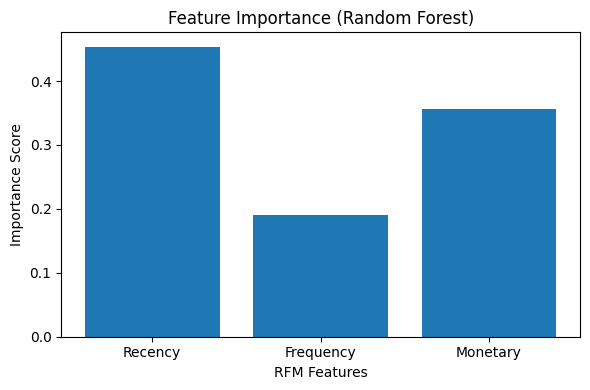

In [35]:
plt.figure(figsize=(6,4))
plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title('Feature Importance (Random Forest)')
plt.xlabel('RFM Features')
plt.ylabel('Importance Score')

plt.tight_layout()
plt.show()

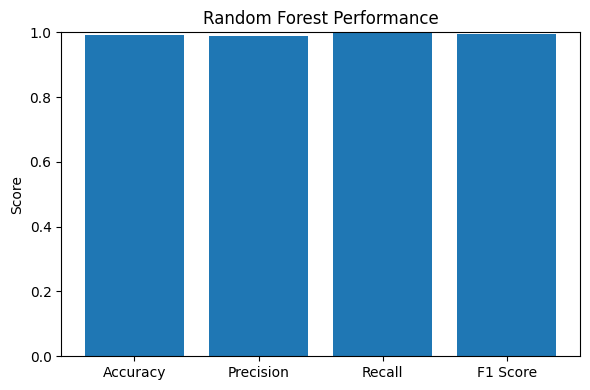

In [36]:
metrics = {
    'Accuracy': accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred),
    'Recall': recall_score(y_test, rf_pred),
    'F1 Score': f1_score(y_test, rf_pred)
}

plt.figure(figsize=(6,4))
plt.bar(metrics.keys(), metrics.values())

plt.title('Random Forest Performance')
plt.ylabel('Score')
plt.ylim(0,1)

plt.tight_layout()
plt.show()